In [ ]:
"""
Cat vs Dog Image Classifier — Transfer Learning with MobileNetV2
Run this in Google Colab (or locally with TensorFlow installed).

"""
!pip install --upgrade --no-deps tensorflow-datasets protobuf

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# ---------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[20%:]'],
    with_info=True,
    as_supervised=True,
)
class_names = ds_info.features['label'].names
print("Classes:", class_names)

# ---------------------------------------------------------
# 2. Preprocess: resize every image to the same shape
# ---------------------------------------------------------
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_dataset = (train_ds.map(preprocess)
                          .shuffle(1000)
                          .batch(BATCH_SIZE)
                          .prefetch(tf.data.AUTOTUNE))
validation_dataset = (val_ds.map(preprocess)
                             .batch(BATCH_SIZE)
                             .prefetch(tf.data.AUTOTUNE))

# ---------------------------------------------------------
# 3. Data augmentation — only affects training data.
#    Randomly flips/rotates images so the model sees more
#    variety and doesn't just memorize exact training photos.
# ---------------------------------------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ---------------------------------------------------------
# 4. Build the model: pretrained MobileNetV2 + custom head
# ---------------------------------------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze for the first training phase

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Phase 1: training the new top layer only ---")
history = model.fit(train_dataset, epochs=5, validation_data=validation_dataset)

# ---------------------------------------------------------
# 5. Fine-tuning: unfreeze the top part of MobileNetV2 and
#    train a bit more with a much lower learning rate.
#    This lets the pretrained features adjust slightly to
#    your specific dataset, usually improving accuracy further.
# ---------------------------------------------------------
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30  # unfreeze only the last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Phase 2: fine-tuning the top layers of MobileNetV2 ---")
fine_tune_epochs = 5
history_fine = model.fit(train_dataset,
                          epochs=fine_tune_epochs,
                          validation_data=validation_dataset)

# ---------------------------------------------------------
# 6. Plot accuracy/loss so you can see training progress
# ---------------------------------------------------------
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=5, color='gray', linestyle='--', label='Start of fine-tuning')
plt.legend()
plt.title('Accuracy over training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

final_val_accuracy = history_fine.history['val_accuracy'][-1]
print(f"Final validation accuracy: {final_val_accuracy:.2%}")

# ---------------------------------------------------------
# 7. Save the trained model so you don't have to retrain
#    every time you want to use it (e.g. in the Gradio app).
# ---------------------------------------------------------
model.save('cat_dog_classifier.keras')
print("\nModel saved as cat_dog_classifier.keras")

It appears there's an issue with the `tensorflow_datasets` installation, possibly due to a `protobuf` version conflict. Let's try reinstalling and upgrading both packages to ensure compatibility. The `--no-deps` flag is used to prevent reinstallation of all dependencies, which can sometimes reintroduce the same compatibility issues.

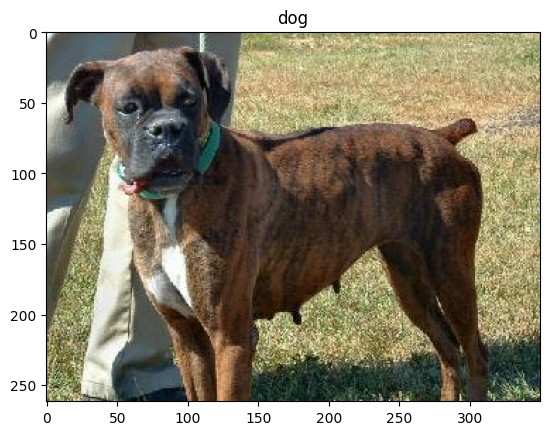

In [ ]:
import matplotlib.pyplot as plt

for image, label in train_ds.take(1):
    plt.imshow(image.numpy())
    plt.title(ds_info.features['label'].names[label.numpy()])
    plt.show()

In [ ]:
"""
Gradio web demo for the Cat vs Dog classifier.
"""

import gradio as gr
import tensorflow as tf
import numpy as np

IMG_SIZE = (160, 160)
CLASS_NAMES = ['cat', 'dog']

model = tf.keras.models.load_model('cat_dog_classifier.keras')

# How close to 0.5 counts as "not confident enough to guess"
UNCERTAINTY_MARGIN = 0.15


def predict(image):
    """
    image: a PIL image handed to us automatically by Gradio.
    Returns a dictionary of {label: confidence} that Gradio's
    Label component knows how to display as a bar chart.
    """
    img = tf.image.resize(np.array(image), IMG_SIZE)
    img = tf.expand_dims(img, axis=0)  # model expects a batch, so add a batch dimension of 1

    prediction = model.predict(img)[0][0]  # a single number between 0 and 1

    dog_confidence = float(prediction)
    cat_confidence = 1 - dog_confidence

    # If the prediction sits close to 0.5, the model is unsure —
    # this is our practical (partial) fix for the "apple -> cat" problem.
    # It won't recognize unrelated objects, but it will at least flag
    # low-confidence guesses instead of stating them as fact.
    if abs(dog_confidence - 0.5) < UNCERTAINTY_MARGIN:
        note = "⚠️ Low confidence — this may not be a cat or dog at all."
    else:
        note = ""

    return {
        "cat": cat_confidence,
        "dog": dog_confidence,
    }, note


demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload a photo"),
    outputs=[
        gr.Label(num_top_classes=2, label="Prediction"),
        gr.Textbox(label="Note"),
    ],
    title="Cat vs Dog Classifier",
    description=(
        "Upload a photo and the model will predict cat or dog, "
        "using transfer learning on MobileNetV2. "
        "Note: this model only knows cats and dogs — images of anything else "
        "will still get forced into one of those two categories, though low-confidence "
        "predictions will be flagged."
    ),
)

if __name__ == "__main__":
    demo.launch()